In [25]:
"""Setup: load from data/processed/raw"""

from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

CSV_FILE = (Path.cwd() / "../data/raw/TruckInspection_score5_completed_merged_Dec10_2025.csv").resolve()

print(f"CSV_FILE : {CSV_FILE}")
print(f"Exists   : {CSV_FILE.exists()}")

# ── Qualtrics exports have two header rows:
#    Row 0  →  human-readable question labels   (becomes column names)
#    Row 1  →  Qualtrics import-ID metadata      (skip)
#    Row 2+ →  actual respondent data
raw = pd.read_csv(CSV_FILE, skiprows=[1])   # keep row 0 as column names, drop row 1
df  = raw.iloc[1:].reset_index(drop=True)   # drop the remaining metadata row

print(f"\nRows × Columns: {df.shape}")

CSV_FILE : /Users/johncao/Documents/GitHub/Inspection-Research/data/raw/TruckInspection_score5_completed_merged_Dec10_2025.csv
Exists   : True

Rows × Columns: (95, 481)


In [26]:
# Fetch Question Labels

for i, col in enumerate(df.columns):
    print(f"{i:3d}  {col}")

  0  StartDate
  1  EndDate
  2  Status
  3  IPAddress
  4  Progress
  5  Duration (in seconds)
  6  Finished
  7  RecordedDate
  8  ResponseId
  9  RecipientLastName
 10  RecipientFirstName
 11  RecipientEmail
 12  ExternalReference
 13  LocationLatitude
 14  LocationLongitude
 15  DistributionChannel
 16  UserLanguage
 17  Q_RecaptchaScore
 18  Q5
 19  Q7
 20  Q8
 21  Q9
 22  Q11
 23  Q11_3_TEXT
 24  Q37
 25  Q37_6_TEXT
 26  Q2-round1
 27  Q2_10_TEXT
 28  Q16
 29  Q16_10_TEXT
 30  Q17
 31  Q17_10_TEXT
 32  Q24
 33  Q24_10_TEXT
 34  Q23
 35  Q23_10_TEXT
 36  Q22
 37  Q22_10_TEXT
 38  Q21
 39  Q21_10_TEXT
 40  Q20
 41  Q20_10_TEXT
 42  Q19
 43  Q19_10_TEXT
 44  Q18
 45  Q18_10_TEXT
 46  Q119_round2
 47  Q119_10_TEXT
 48  Q120
 49  Q120_10_TEXT
 50  Q121
 51  Q121_10_TEXT
 52  Q122
 53  Q122_10_TEXT
 54  Q123
 55  Q123_10_TEXT
 56  Q124
 57  Q124_10_TEXT
 58  Q125
 59  Q125_10_TEXT
 60  Q126
 61  Q126_10_TEXT
 62  Q127
 63  Q127_10_TEXT
 64  Q128
 65  Q128_10_TEXT
 66  Q144-round3
 67  

In [27]:
# Quick Look on first 5 cols

KEY_COLS = [
    "StartDate", "EndDate", "Duration (in seconds)",
    "Q5",    # consent
    "Q7",    # email
    "Q8",    # organization
    "Q9",    # job title
    "Q11",   # inspection licenses
    "Q37",   # major / field of study
    "Q2-round1",  # factors used in decision-making (round 1)
    "score",
    "total_score1",
]

df[KEY_COLS].head()

,StartDate,EndDate,Duration (in seconds),Q5,Q7,Q8,Q9,Q11,Q37,Q2-round1,score,total_score1
0,2023-11-02 18:02,2023-11-02 18:27,1480,"I consent, begin the study",NaN,NaN,NaN,I don't have any license,Civil Engineering,"Brake pad thickness in the last inspection,Gro...",0,"0.625,0.5,0.375,0.5,0.625,0.5,0.75,0.625,0.625..."
1,2023-11-03 12:43,2023-11-03 16:12,12538,"I consent, begin the study",miaosid@andrew.cmu.edu,Carnegie Mellon University,Ph.D. Student,I don't have any license,Civil Engineering,Vehicle age,0,"0.5,0.5,0.375,0.5,0.375,0.625,0.5,0.25,0.375,0..."
2,2023-11-05 2:03,2023-11-05 2:44,2492,"I consent, begin the study",avaj@andrew.cmu.edu,Carnegie Mellon University,Graduate research assistant,I don't have any license,Civil Engineering,"Brake pad thickness in the last inspection,Veh...",0,"0.625,0.5,0.5,0.75,0.625,0.875,0.75,1,1,"
3,2023-11-06 14:56,2023-11-06 21:20,23065,"I consent, begin the study",ptang@andrew.cmu.edu,"Carnegie Mellon University, Civil and Environm...",Associate Professor,I don't have any license,"Civil Engineering,Industrial & Operations Engi...","Brake pad thickness in the last inspection,Gro...",0,"0.5,0.625,0.5,0.75,0.75,"
4,2023-11-02 23:12,2023-11-08 11:05,478409,"I consent, begin the study",pengkunl@andrew.cmu.edu,Carnegie Mellon University,PhD Candidate,I don't have any license,Civil Engineering,"Brake pad thickness in the last inspection,Gro...",0,"0.25,0.375,0.625,0.5,0.75,0.75,"


In [28]:
# Random sample of 5 respondents

df[KEY_COLS].sample(5, random_state=42)

,StartDate,EndDate,Duration (in seconds),Q5,Q7,Q8,Q9,Q11,Q37,Q2-round1,score,total_score1
68,2025-06-09 17:57,2025-06-09 18:17,1191,"I consent, begin the study",madabs2418@gmail.com,Suburban,electrician,I don't have any license,Electrical or Computer Engineering,"Brake pad thickness in the last inspection,Veh...",0,"0.5,0.5,0.25,0.625,0.75,"
22,2025-03-15 11:18,2025-03-18 7:52,246813,"I consent, begin the study",ptang@andrew.cmu.edu,vvy,fdh,I don't have any license,Civil Engineering,"Brake pad thickness in the last inspection,Veh...",0,"0.625,0.5,0.75,"
72,2025-06-09 17:57,2025-06-09 22:40,16975,"I consent, begin the study",Normanhmartell@hotmail.com,Hospitality & Tourism,manger,Certificate by Federal Motor Carrier Safety Ad...,Industrial & Operations Engineering,"Gross vehicle weight,Vehicle age,Vehicle make,...",0,"0.25,0.5,0.5,0.625,0.75,"
73,2025-06-19 23:26,2025-06-19 23:50,1462,"I consent, begin the study",NaN,NaN,NaN,I don't have any license,Electrical or Computer Engineering,"Brake pad thickness in the last inspection,Mil...",0,"0.625,0.625,0.625,0.5,0.75,"
0,2023-11-02 18:02,2023-11-02 18:27,1480,"I consent, begin the study",NaN,NaN,NaN,I don't have any license,Civil Engineering,"Brake pad thickness in the last inspection,Gro...",0,"0.625,0.5,0.375,0.5,0.625,0.5,0.75,0.625,0.625..."


In [29]:
# Row and column counts 

print(f"Respondents  : {len(df)}")
print(f"Total columns: {df.shape[1]}")

Respondents  : 95
Total columns: 481


In [30]:
# Respondent profiles

print("=== Q11: Inspection licenses ===")
print(df["Q11"].value_counts().to_string(), "\n")

print("=== Q37: Field of study ===")
print(df["Q37"].value_counts().to_string(), "\n")

df["duration_min"] = pd.to_numeric(df["Duration (in seconds)"], errors="coerce") / 60
print("=== Survey duration (minutes) ===")
print(df["duration_min"].describe().round(1))

=== Q11: Inspection licenses ===
Q11
I don't have any license                                                                                    75
Certificate by Federal Motor Carrier Safety Administration                                                  10
Class 3 inspection license certificated by PA                                                                5
Certificate by Federal Motor Carrier Safety Administration,Class 3 inspection license certificated by PA     3
Other                                                                                                        2 

=== Q37: Field of study ===
Q37
Computer Science                                                                           26
Civil Engineering                                                                          23
Others                                                                                     15
Electrical or Computer Engineering                                                          

                                            count  pct_respondents
Brake pad thickness in the last inspection     83             87.4
Mileage driven in the last year                63             66.3
Vehicle age                                    57             60.0
Gross vehicle weight                           48             50.5
Region                                         33             34.7
Odometer in the last inspection                28             29.5
Brake location                                 18             18.9
Vehicle make                                   15             15.8
Vehicle body                                    9              9.5
Others not mentioned in the experiment          1              1.1


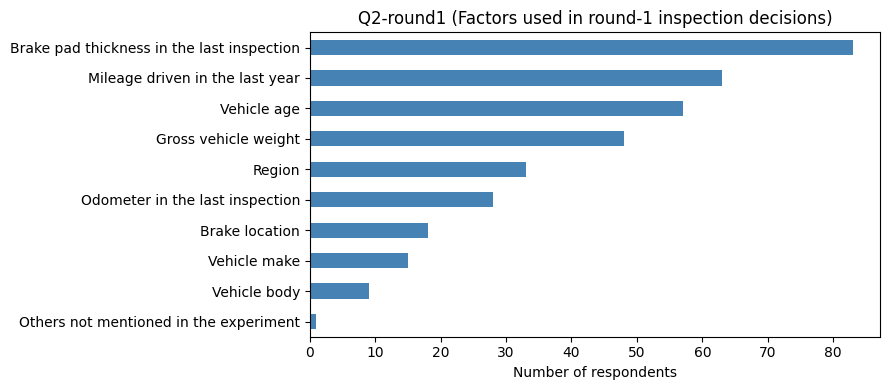

In [31]:
# Q2

factor_counts = Counter()
for row in df["Q2-round1"].dropna():
    for f in row.split(","):
        factor_counts[f.strip()] += 1

factor_df = (
    pd.DataFrame.from_dict(factor_counts, orient="index", columns=["count"])
    .sort_values("count", ascending=False)
)
factor_df["pct_respondents"] = (factor_df["count"] / len(df) * 100).round(1)

print(factor_df.to_string())

# ── bar chart
fig, ax = plt.subplots(figsize=(9, 4))
factor_df["count"].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of respondents")
ax.set_title("Q2-round1 (Factors used in round-1 inspection decisions)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [32]:
# Block responses (B1–B5)
# BxRes_N stores the inspector's decision for scenario block x, truck N.
# Values are semicolon-delimited component tags, e.g. 'brake;tire;light;'.


N_BLOCKS = 5

for b in range(1, N_BLOCKS + 1):
    res_cols = [f"B{b}Res_{n}" for n in range(1, 9)]
    block_data = df[res_cols].stack().dropna()
    value_counts = block_data.value_counts()
    n_respondents = df[f"B{b}Res_1"].notna().sum()
    print(f"\n=== Block {b}  ({n_respondents} respondents) ===")
    print(value_counts.head(10).to_string())


=== Block 1  (95 respondents) ===
no;                             225
brake;                          223
brake;tire;                      41
brake;light;                     29
brake;suspension;                22
brake;tire;light;suspension;     18
no;suspension;                   16
brake;tire;suspension;           13
brake;no;dbrake;                 12
no;light;                        12

=== Block 2  (95 respondents) ===
no;                             287
brake;                          221
brake;light;                     30
brake;tire;                      26
brake;tire;light;suspension;     22
no;suspension;                   15
brake;suspension;                13
no;tire;                         12
no;light;                        11
no;brake;dno;                     9

=== Block 3  (94 respondents) ===
no;                             277
brake;                          241
brake;light;                     37
brake;tire;                      20
no;tire;light;suspension;      

       pass  fail
block            
B1      225   534
B2      287   473
B3      277   472
B4      309   448
B5      338   412


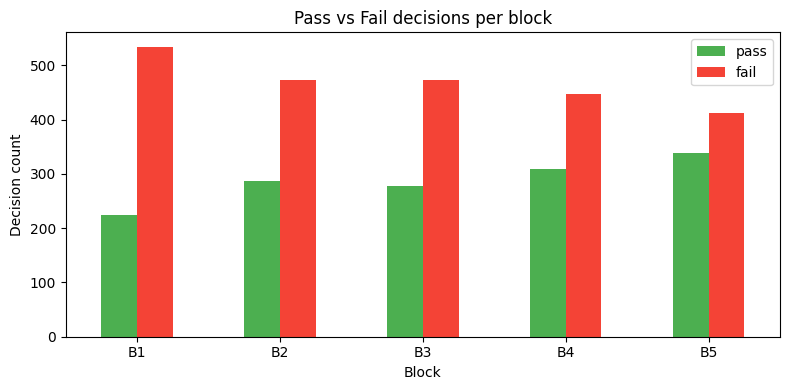

In [33]:
# Pass / Fail breakdown per block

# A decision of 'no;' = pass (no defect found).
# Anything else = fail (defect flagged).


N_BLOCKS = 5
summary = []

for b in range(1, N_BLOCKS + 1):
    res_cols = [f"B{b}Res_{n}" for n in range(1, 9)]
    block_data = df[res_cols].stack().dropna()
    n_pass = (block_data == "no;").sum()
    n_fail = (block_data != "no;").sum()
    summary.append({"block": f"B{b}", "pass": n_pass, "fail": n_fail})

summary_df = pd.DataFrame(summary).set_index("block")
print(summary_df)

summary_df.plot(kind="bar", figsize=(8, 4), color=["#4caf50", "#f44336"])
plt.title("Pass vs Fail decisions per block")
plt.xlabel("Block")
plt.ylabel("Decision count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== Mean accuracy per respondent ===
count    95.000
mean      0.576
std       0.121
min       0.312
25%       0.500
50%       0.562
75%       0.625
max       1.000
Name: mean_accuracy, dtype: float64


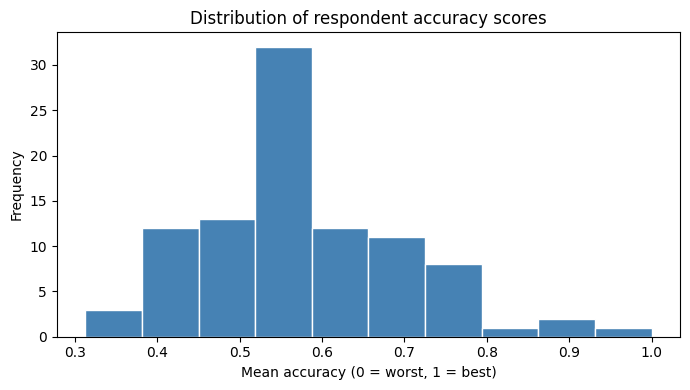

In [34]:
# Accuracy scores per respondent (total_score1)

# total_score1 is a comma-separated list of per-trial scores (0–1).
# We parse each respondent's scores and compute their mean accuracy.


def parse_scores(s):
    """Return list of floats from a comma-separated score string."""
    if pd.isna(s):
        return []
    return [float(x) for x in str(s).split(",") if x.strip() != ""]

df["scores_list"]  = df["total_score1"].apply(parse_scores)
df["mean_accuracy"] = df["scores_list"].apply(lambda lst: sum(lst) / len(lst) if lst else None)

print("=== Mean accuracy per respondent ===")
print(df["mean_accuracy"].describe().round(3))

df["mean_accuracy"].dropna().plot(
    kind="hist", bins=10, figsize=(7, 4),
    color="steelblue", edgecolor="white"
)
plt.xlabel("Mean accuracy (0 = worst, 1 = best)")
plt.title("Distribution of respondent accuracy scores")
plt.tight_layout()
plt.show()

=== Mind-change (dno) counts per respondent ===
count    95.00
mean     20.63
std      16.19
min       0.00
25%       8.00
50%      16.00
75%      24.00
max      80.00
Name: dno_count, dtype: float64

Respondents with at least one mind-change: 84 / 95

=== Vehicle slots with most mind-changes (top 10) ===
B1sresponse_1    72
B1sresponse_3    72
B1sresponse_4    72
B1sresponse_5    72
B1sresponse_6    72
B1sresponse_7    72
B1sresponse_8    72
B1sresponse_2    72
B2sresponse_5    53
B2sresponse_8    53


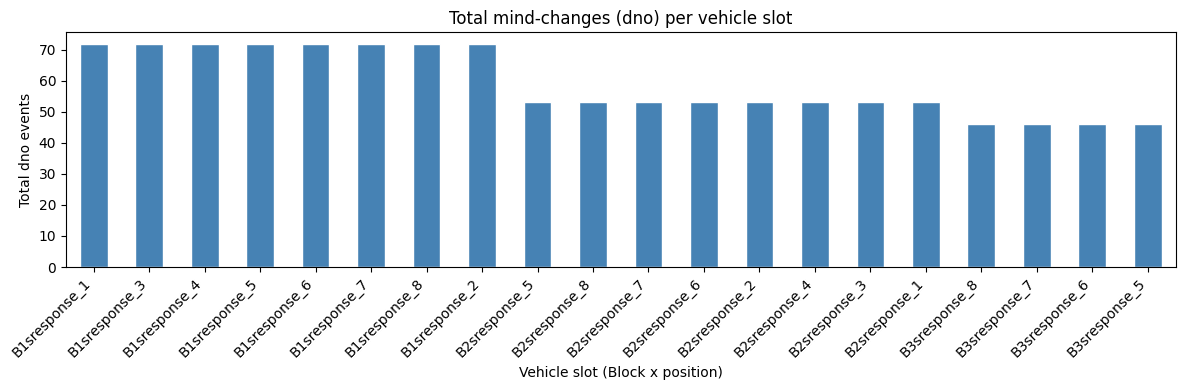

In [35]:
# The "dno" Phenomenon
# sresponse columns store the full semicolon-delimited click history for each
# vehicle decision. A "dno" token means the participant changed their mind
# from "no inspection" back to "yes inspection".

all_sresponse = [f"B{b}sresponse_{n}" for b in range(1, 6) for n in range(1, 9)]

def count_dno(row):
    total = 0
    for col in all_sresponse:
        val = row.get(col, "")
        if pd.isna(val) or val == "":
            continue
        total += str(val).count("dno")
    return total

df["dno_count"] = df.apply(count_dno, axis=1)

print("=== Mind-change (dno) counts per respondent ===")
print(df["dno_count"].describe().round(2))
print(f"\nRespondents with at least one mind-change: {(df['dno_count'] > 0).sum()} / {len(df)}")

# Which vehicle slots triggered the most mind-changes?
col_dno = {}
for col in all_sresponse:
    col_dno[col] = df[col].dropna().apply(lambda v: str(v).count("dno")).sum()

dno_series = (
    pd.Series(col_dno)
      .sort_values(ascending=False)
      .rename("dno_total")
)
print("\n=== Vehicle slots with most mind-changes (top 10) ===")
print(dno_series.head(10).to_string())

dno_series.head(20).plot(kind="bar", figsize=(12, 4), color="steelblue", edgecolor="white")
plt.title("Total mind-changes (dno) per vehicle slot")
plt.xlabel("Vehicle slot (Block x position)")
plt.ylabel("Total dno events")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [39]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "-q"])


0

In [40]:
# Vehicle Feature Sensitivity
# Uses B(n)loopId to identify each vehicle shown, joins the codebook
# vehicle lookup table, then fits a logistic regression to find which
# features best predict the binary inspect/not-inspect decision (BxYbtn).

import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Vehicle lookup table (40 vehicles from codebook)
VEHICLES = {"1": {"make": "STERLING TRUCK", "body": "Truck", "weight": "Class 8", "region": "Small metro", "age": 18, "odometer": 55896, "mileage": 2187, "brake_loc": "Left Front", "brake_pad": 6}, "2": {"make": "INTERNATIONAL", "body": "Truck-Tractor", "weight": "Class 8", "region": "Micropolitan", "age": 25, "odometer": 364389, "mileage": 833, "brake_loc": "Left Front", "brake_pad": 4}, "3": {"make": "FREIGHTLINER", "body": "Truck-Tractor", "weight": "Class 8", "region": "Micropolitan", "age": 22, "odometer": 42578, "mileage": 1393, "brake_loc": "Left Front", "brake_pad": 4}, "4": {"make": "FORD", "body": "Truck", "weight": "Class 7", "region": "Small metro", "age": 24, "odometer": 101931, "mileage": 309, "brake_loc": "Left Front", "brake_pad": 5}, "5": {"make": "INTERNATIONAL", "body": "Truck-Tractor", "weight": "Class 8", "region": "Micropolitan", "age": 25, "odometer": 364389, "mileage": 833, "brake_loc": "Right Front", "brake_pad": 4}, "6": {"make": "MACK", "body": "Truck", "weight": "Class 8", "region": "Large fringe metro", "age": 19, "odometer": 275506, "mileage": 6980, "brake_loc": "Left Rear", "brake_pad": 3}, "7": {"make": "PETERBILT", "body": "Truck", "weight": "Class 8", "region": "Micropolitan", "age": 11, "odometer": 431811, "mileage": 3835, "brake_loc": "Left Front", "brake_pad": 4}, "8": {"make": "FORD", "body": "Truck", "weight": "Class 7", "region": "Small metro", "age": 26, "odometer": 102287, "mileage": 819, "brake_loc": "Right Front", "brake_pad": 5}, "9": {"make": "MACK", "body": "Truck", "weight": "Class 8", "region": "Medium metro", "age": 36, "odometer": 112102, "mileage": 3830, "brake_loc": "Left Rear", "brake_pad": 7}, "10": {"make": "PETERBILT", "body": "Truck", "weight": "Class 8", "region": "Medium metro", "age": 38, "odometer": 736136, "mileage": 3967, "brake_loc": "Right Rear", "brake_pad": 7}, "11": {"make": "MACK", "body": "Truck-Tractor", "weight": "Class 8", "region": "Large fringe metro", "age": 28, "odometer": 306222, "mileage": 16519, "brake_loc": "Left Front", "brake_pad": 10}, "12": {"make": "KENWORTH", "body": "Truck", "weight": "Class 8", "region": "Large fringe metro", "age": 22, "odometer": 495359, "mileage": 18322, "brake_loc": "Right Rear", "brake_pad": 8}, "13": {"make": "FREIGHTLINER", "body": "Truck", "weight": "Class 7", "region": "Medium metro", "age": 8, "odometer": 288942, "mileage": 17755, "brake_loc": "Left Front", "brake_pad": 9}, "14": {"make": "MACK", "body": "Truck", "weight": "Class 8", "region": "Large fringe metro", "age": 13, "odometer": 279474, "mileage": 16716, "brake_loc": "Right Rear", "brake_pad": 8}, "15": {"make": "KENWORTH", "body": "Truck", "weight": "Class 8", "region": "Small metro", "age": 9, "odometer": 118320, "mileage": 14384, "brake_loc": "Left Rear", "brake_pad": 10}, "16": {"make": "PETERBILT", "body": "Truck-Tractor", "weight": "Class 8", "region": "Large fringe metro", "age": 15, "odometer": 1010325, "mileage": 17354, "brake_loc": "Right Front", "brake_pad": 8}, "17": {"make": "KENWORTH", "body": "Truck-Tractor", "weight": "Class 8", "region": "Small metro", "age": 9, "odometer": 231568, "mileage": 12665, "brake_loc": "Left Front", "brake_pad": 8}, "18": {"make": "PETERBILT", "body": "Truck", "weight": "Class 8", "region": "Medium metro", "age": 8, "odometer": 100934, "mileage": 14211, "brake_loc": "Left Front", "brake_pad": 10}, "19": {"make": "INTERNATIONAL", "body": "Truck", "weight": "Class 7", "region": "Medium metro", "age": 2, "odometer": 91583, "mileage": 19835, "brake_loc": "Left Rear", "brake_pad": 10}, "20": {"make": "PETERBILT", "body": "Truck-Tractor", "weight": "Class 8", "region": "Large fringe metro", "age": 8, "odometer": 72642, "mileage": 13391, "brake_loc": "Left Rear", "brake_pad": 9}, "21": {"make": "MACK", "body": "Truck", "weight": "Class 8", "region": "Large fringe metro", "age": 23, "odometer": 461416, "mileage": 3777, "brake_loc": "Left Rear", "brake_pad": 10}, "22": {"make": "FREIGHTLINER", "body": "Truck", "weight": "Class 7", "region": "Medium metro", "age": 18, "odometer": 39532, "mileage": 911, "brake_loc": "Right Front", "brake_pad": 15}, "23": {"make": "INTERNATIONAL", "body": "Truck-Tractor", "weight": "Class 8", "region": "Medium metro", "age": 4, "odometer": 155052, "mileage": 251, "brake_loc": "Right Rear", "brake_pad": 9}, "24": {"make": "MACK", "body": "Truck-Tractor", "weight": "Class 8", "region": "Large central metro", "age": 15, "odometer": 632425, "mileage": 473, "brake_loc": "Right Rear", "brake_pad": 14}, "25": {"make": "FORD", "body": "Truck", "weight": "Class 7", "region": "Large fringe metro", "age": 35, "odometer": 215480, "mileage": 820, "brake_loc": "Left Front", "brake_pad": 10}, "26": {"make": "STERLING TRUCK", "body": "Truck", "weight": "Class 8", "region": "Small metro", "age": 20, "odometer": 86965, "mileage": 2724, "brake_loc": "Right Front", "brake_pad": 14}, "27": {"make": "FORD", "body": "Truck", "weight": "Class 8", "region": "Micropolitan", "age": 22, "odometer": 49821, "mileage": 3316, "brake_loc": "Left Rear", "brake_pad": 10}, "28": {"make": "FREIGHTLINER", "body": "Truck-Tractor", "weight": "Class 8", "region": "Medium metro", "age": 26, "odometer": 871988, "mileage": 4832, "brake_loc": "Right Front", "brake_pad": 8}, "29": {"make": "MACK", "body": "Truck", "weight": "Class 8", "region": "Large fringe metro", "age": 19, "odometer": 125459, "mileage": 3431, "brake_loc": "Left Front", "brake_pad": 10}, "30": {"make": "FORD", "body": "Truck", "weight": "Class 7", "region": "Medium metro", "age": 23, "odometer": 87291, "mileage": 3060, "brake_loc": "Left Front", "brake_pad": 8}, "31": {"make": "MACK", "body": "Truck-Tractor", "weight": "Class 8", "region": "Large fringe metro", "age": 28, "odometer": 306222, "mileage": 16519, "brake_loc": "Left Front", "brake_pad": 10}, "32": {"make": "INTERNATIONAL", "body": "Truck", "weight": "Class 8", "region": "Medium metro", "age": 6, "odometer": 90892, "mileage": 10625, "brake_loc": "Left Front", "brake_pad": 9}, "33": {"make": "STERLING TRUCK", "body": "Truck", "weight": "Class 8", "region": "Micropolitan", "age": 12, "odometer": 293683, "mileage": 20602, "brake_loc": "Left Rear", "brake_pad": 18}, "34": {"make": "FREIGHTLINER", "body": "Truck", "weight": "Class 7", "region": "Micropolitan", "age": 17, "odometer": 251493, "mileage": 7976, "brake_loc": "Left Rear", "brake_pad": 16}, "35": {"make": "KENWORTH", "body": "Truck", "weight": "Class 8", "region": "Large fringe metro", "age": 22, "odometer": 495359, "mileage": 18322, "brake_loc": "Right Rear", "brake_pad": 8}, "36": {"make": "GMC", "body": "Truck", "weight": "Class 8", "region": "Large fringe metro", "age": 13, "odometer": 132153, "mileage": 5584, "brake_loc": "Left Front", "brake_pad": 8}, "37": {"make": "FREIGHTLINER", "body": "Truck", "weight": "Class 7", "region": "Medium metro", "age": 8, "odometer": 288942, "mileage": 17755, "brake_loc": "Left Front", "brake_pad": 9}, "38": {"make": "FREIGHTLINER", "body": "Truck", "weight": "Class 7", "region": "Medium metro", "age": 15, "odometer": 354825, "mileage": 12388, "brake_loc": "Left Rear", "brake_pad": 8}, "39": {"make": "FORD", "body": "Truck", "weight": "Class 7", "region": "Medium metro", "age": 34, "odometer": 688526, "mileage": 7757, "brake_loc": "Left Front", "brake_pad": 8}, "40": {"make": "FREIGHTLINER", "body": "Truck", "weight": "Class 7", "region": "Medium metro", "age": 8, "odometer": 288942, "mileage": 17755, "brake_loc": "Left Front", "brake_pad": 9}}
vehicle_df = pd.DataFrame(VEHICLES).T
vehicle_df.index.name = 'vehicle_id'

# Build long-form decision table: one row per (respondent, block, vehicle)
records = []
for b in range(1, 6):
    for n in range(1, 9):
        loop_col = f'B{b}loopId_{n}'
        ybtn_col = f'B{b}ybtn_{n}'
        for _, row in df[[loop_col, ybtn_col]].dropna().iterrows():
            try:
                vid  = int(float(row[loop_col]))
                ybtn = int(float(row[ybtn_col]))
            except (ValueError, TypeError):
                continue
            if vid in VEHICLES:
                records.append({'vehicle_id': vid, 'inspected': ybtn, 'block': b, 'position': n})

decisions = pd.DataFrame(records).merge(vehicle_df.reset_index(), on='vehicle_id')
for col in ['brake_pad', 'age', 'odometer', 'mileage']:
    decisions[col] = pd.to_numeric(decisions[col], errors='coerce')
print(f'Total decision records: {len(decisions)}')

# Inspection rate by brake pad thickness
bp_rate = (
    decisions.groupby('brake_pad')['inspected']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'inspect_rate', 'count': 'n'})
              .sort_index()
)
print('\n=== Inspection rate by brake pad thickness (32nds of an inch) ===')
print(bp_rate.round(3).to_string())

bp_rate['inspect_rate'].plot(kind='bar', figsize=(9, 4), color='steelblue', edgecolor='white')
plt.xlabel('Brake pad thickness (32nds of an inch)')
plt.ylabel('Proportion inspected')
plt.title('Inspection rate by brake pad thickness')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Logistic regression
features = ['brake_pad', 'age', 'odometer', 'mileage', 'weight', 'region', 'brake_loc']
model_data = decisions[features + ['inspected']].dropna().copy()
for col in ['weight', 'region', 'brake_loc']:
    model_data[col] = LabelEncoder().fit_transform(model_data[col])

lr = LogisticRegression(max_iter=500)
lr.fit(model_data[features], model_data['inspected'])

coef_df = (
    pd.DataFrame({'feature': features, 'coefficient': lr.coef_[0]})
      .sort_values('coefficient', key=abs, ascending=False)
)
print('\n=== Logistic regression coefficients (what drives inspection decisions) ===')
print(coef_df.to_string(index=False))

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in coef_df['coefficient']]
coef_df.set_index('feature')['coefficient'].plot(kind='barh', figsize=(8, 4), color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Logistic regression coefficient')
plt.title('Feature influence on inspection decision\n(green = more likely to inspect, red = less likely)')
plt.tight_layout()
plt.show()


KeyError: 'vehicle_id'

=== Normalized field of study ===
major_norm
Computer Science                       27
Civil Engineering                      25
Others                                 15
Electrical or Computer Engineering     14
Mechanical Engineering                 11
Industrial & Operations Engineering     3

=== Mean accuracy by field of study ===
                                     mean_accuracy   n
major_norm                                            
Mechanical Engineering                       0.642  11
Civil Engineering                            0.614  25
Electrical or Computer Engineering           0.590  14
Industrial & Operations Engineering          0.589   3
Others                                       0.561  15
Computer Science                             0.512  27


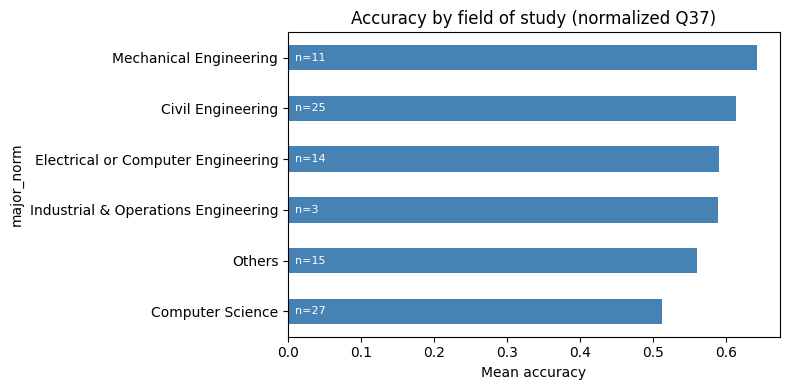


=== Mean accuracy by license status (Q11) ===
             mean_accuracy   n
No license           0.572  75
Has license          0.587  20


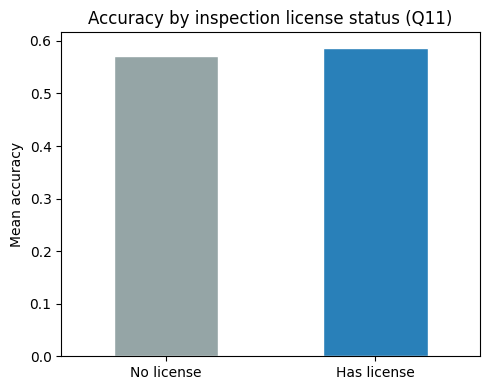

In [38]:
# Expertise Effects
# Compares accuracy across field of study (Q37) and license status (Q11).
#
# NOTE: Q37 conflates 'Mechanics Engineering' and 'Mechanical Engineering'
# as separate response options — they are the same field. The normalization
# below merges them. Other similar inconsistencies may exist and should be
# reviewed manually before drawing conclusions from subgroup comparisons.

# Re-derive mean_accuracy if not already present
if 'mean_accuracy' not in df.columns:
    def parse_scores(s):
        if pd.isna(s): return []
        return [float(x) for x in str(s).split(',') if x.strip() != '']
    df['scores_list']   = df['total_score1'].apply(parse_scores)
    df['mean_accuracy'] = df['scores_list'].apply(lambda l: sum(l)/len(l) if l else None)

# Normalize Q37
def normalize_major(val):
    if pd.isna(val):
        return val
    val = val.replace('Mechanics Engineering', 'Mechanical Engineering')
    return val.split(',')[0].strip()

df['major_norm'] = df['Q37'].apply(normalize_major)

print('=== Normalized field of study ===')
print(df['major_norm'].value_counts().to_string())

# Accuracy by field of study
accuracy_by_major = (
    df.dropna(subset=['mean_accuracy', 'major_norm'])
      .groupby('major_norm')['mean_accuracy']
      .agg(['mean', 'count'])
      .sort_values('mean', ascending=False)
      .round(3)
)
accuracy_by_major.columns = ['mean_accuracy', 'n']
print('\n=== Mean accuracy by field of study ===')
print(accuracy_by_major.to_string())

ax = accuracy_by_major['mean_accuracy'].plot(kind='barh', figsize=(8, 4), color='steelblue')
for i, (_, row) in enumerate(accuracy_by_major.iterrows()):
    ax.text(0.01, i, f"n={int(row['n'])}", va='center', fontsize=8, color='white')
plt.xlabel('Mean accuracy')
plt.title('Accuracy by field of study (normalized Q37)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Accuracy by license status (Q11)
df['has_license'] = ~df['Q11'].str.contains("don't have", case=False, na=True)

accuracy_by_license = (
    df.dropna(subset=['mean_accuracy'])
      .groupby('has_license')['mean_accuracy']
      .agg(['mean', 'count'])
      .round(3)
)
accuracy_by_license.index = ['No license', 'Has license']
accuracy_by_license.columns = ['mean_accuracy', 'n']
print('\n=== Mean accuracy by license status (Q11) ===')
print(accuracy_by_license.to_string())

accuracy_by_license['mean_accuracy'].plot(
    kind='bar', figsize=(5, 4), color=['#95a5a6', '#2980b9'], edgecolor='white'
)
plt.ylabel('Mean accuracy')
plt.title('Accuracy by inspection license status (Q11)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
